#### Task 2: Data Acquisition & Initial Visualization

You may use the provided USGS streamflow datasets or a time-series dataset of your own choosing, provided it has at least daily resolution.

**Load Data:** Read the raw data into a Pandas DataFrame from your  data/ folder.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

In [ ]:
#load data by going up a directory and then into the data folder

blackfork = pd.read_csv('../data/09217900_1980_2020.csv')
greenriver = pd.read_csv('../data/09234500_1980_2020.csv')
bear_upper = pd.read_csv('../data/10011500_1980_2020.csv')
bear_lower = pd.read_csv('../data/10126000_1980_2020.csv')

greenriver.head() #check that data loaded correctly


,Datetime,USGS_flow,variable,USGS_ID,measurement_unit,qualifiers,series
0,1986-10-01,2139.7144,streamflow,9234500,ft3/s,"['A', '[91]']",0
1,1986-10-02,2295.4167,streamflow,9234500,ft3/s,"['A', '[91]']",0
2,1986-10-03,2061.4792,streamflow,9234500,ft3/s,"['A', '[91]']",0
3,1986-10-04,2219.3750,streamflow,9234500,ft3/s,"['A', '[91]']",0
4,1986-10-05,1778.7500,streamflow,9234500,ft3/s,"['A', '[91]']",0


**Process the data:** Subset the data so that all of the data is overlapping and is 6 years in length.

I first wanted to know what years are represented in the full data (1980-2020), then chose 6 recent years (2014-2019). These year were chosen arbitrarily. 

In [3]:
# what years does the data cover?
print("Blacks Fork data covers years:", blackfork['Datetime'].min(), "to", blackfork['Datetime'].max())
print("Green River data covers years:", greenriver['Datetime'].min(), "to", greenriver['Datetime'].max())
print("Bear Upper data covers years:", bear_upper['Datetime'].min(), "to", bear_upper['Datetime'].max())
print("Bear Lower data covers years:", bear_lower['Datetime'].min(), "to", bear_lower['Datetime'].max())

# 6 years of data = let's subset 2014-2019
blackfork_subset = blackfork[(blackfork['Datetime'] >= '2014-01-01') & (blackfork['Datetime'] <= '2019-12-31')]
greenriver_subset = greenriver[(greenriver['Datetime'] >= '2014-01-01') & (greenriver['Datetime'] <= '2019-12-31')]
bear_upper_subset = bear_upper[(bear_upper['Datetime'] >= '2014-01-01') & (bear_upper['Datetime'] <= '2019-12-31')]
bear_lower_subset = bear_lower[(bear_lower['Datetime'] >= '2014-01-01') & (bear_lower['Datetime'] <= '2019-12-31')]

print(' ')

#check for NAs
print("Blacks Fork NAs after subset:", blackfork_subset['USGS_flow'].isna().sum())
print("Green River NAs after subset:", greenriver_subset['USGS_flow'].isna().sum())
print("Bear Upper NAs after subset:", bear_upper_subset['USGS_flow'].isna().sum())
print("Bear Lower NAs after subset:", bear_lower_subset['USGS_flow'].isna().sum())



Blacks Fork data covers years: 1992-10-29 to 2020-09-29
Green River data covers years: 1986-10-01 to 2020-09-29
Bear Upper data covers years: 1986-10-01 to 2020-09-29
Bear Lower data covers years: 1986-10-01 to 2020-09-29
 
Blacks Fork NAs after subset: 358
Green River NAs after subset: 0
Bear Upper NAs after subset: 216
Bear Lower NAs after subset: 134


In [4]:
#check for weird values
print('Blacks Fork after subset:\n', blackfork_subset['USGS_flow'].describe(), '\n')
print('Green River after subset:\n', greenriver_subset['USGS_flow'].describe(), '\n')
print('Bear Upper after subset:\n', bear_upper_subset['USGS_flow'].describe(), '\n')
print('Bear Lower after subset:\n', bear_lower_subset['USGS_flow'].describe())

Blacks Fork after subset:
 count    1833.000000
mean      198.014359
std       305.952409
min         2.742917
25%        34.416668
50%        70.145836
75%       223.031250
max      2583.444300
Name: USGS_flow, dtype: float64 

Green River after subset:
 count    2191.000000
mean     2369.497845
std      1845.095997
min       776.104200
25%      1615.104100
50%      1918.229100
75%      2225.317750
max      9174.062500
Name: USGS_flow, dtype: float64 

Bear Upper after subset:
 count    1975.000000
mean      217.066704
std       330.735410
min        24.300000
25%        49.064585
50%        80.654170
75%       195.322915
max      2119.793700
Name: USGS_flow, dtype: float64 

Bear Lower after subset:
 count    2057.000000
mean     1350.945180
std      1325.589600
min        54.891666
25%       415.968750
50%       974.979200
75%      1891.770900
max      9323.333000
Name: USGS_flow, dtype: float64


In [5]:
#check the Blacks Fork high values to make sure they make sense
#get values from the date column of top 10 high flows and sort them by date
top_10_high_flows = blackfork_subset['USGS_flow'].nlargest(10)
top_10_high_flow_dates = blackfork_subset.loc[top_10_high_flows.index, 'Datetime']
print("Index and Dates of top 10 high flows (Blacks Fork):\n", top_10_high_flow_dates.sort_values())

#do the same for bear_lower
top_10_high_flows = bear_lower_subset['USGS_flow'].nlargest(10)
top_10_high_flow_dates = bear_lower_subset.loc[top_10_high_flows.index, 'Datetime']
print("Index and Dates of top 10 high flows (Bear Lower):\n", top_10_high_flow_dates.sort_values())

Index and Dates of top 10 high flows (Blacks Fork):
 8624    2016-06-09
8625    2016-06-10
9717    2019-06-07
9718    2019-06-08
9723    2019-06-13
9724    2019-06-14
9725    2019-06-15
9726    2019-06-16
9727    2019-06-17
9730    2019-06-20
Name: Datetime, dtype: object
Index and Dates of top 10 high flows (Bear Lower):
 11092    2017-02-12
11093    2017-02-13
11094    2017-02-14
11095    2017-02-15
11096    2017-02-16
11104    2017-02-24
11105    2017-02-25
11106    2017-02-26
11136    2017-03-28
11137    2017-03-29
Name: Datetime, dtype: object


After checking the data with describe() and checking the dates of the high values that seemed a little too high, I determined that I'm not going to remove any outliers because there doesn't seem to be any. There are no obvious negative flows, 0 flows, or incredibly high flows. The dates of the highest flows for the lower Bear River are a little strange being in February/March, but they aren't single high values and seem to be a one-time trend for many days in 2017. This year also turned out to be my "wet year" of choice, so these values seems to fit the pattern of the rest of the locations. 

In [6]:
#remove unwanted columns from each subset
blackfork_subset = blackfork_subset.drop(columns=['variable', 'USGS_ID', 'measurement_unit', 'qualifiers', 'series'])
greenriver_subset = greenriver_subset.drop(columns=['variable', 'USGS_ID', 'measurement_unit', 'qualifiers', 'series'])
bear_upper_subset = bear_upper_subset.drop(columns=['variable', 'USGS_ID', 'measurement_unit', 'qualifiers', 'series'])
bear_lower_subset = bear_lower_subset.drop(columns=['variable', 'USGS_ID', 'measurement_unit', 'qualifiers', 'series'])

**Exploratory Data Analysis (EDA):** Create an initial time-series plot of the data, ensure the plot has a title, axes labels, legend. etc. Create a figure with four subplots to visualize the data.

In [7]:
#before plotting create a media directory to save the figure to, if not already created
if not os.path.exists('media'):
    os.makedirs('media')
else:
    print("Media directory already exists, will save figure there")


Media directory already exists, will save figure there


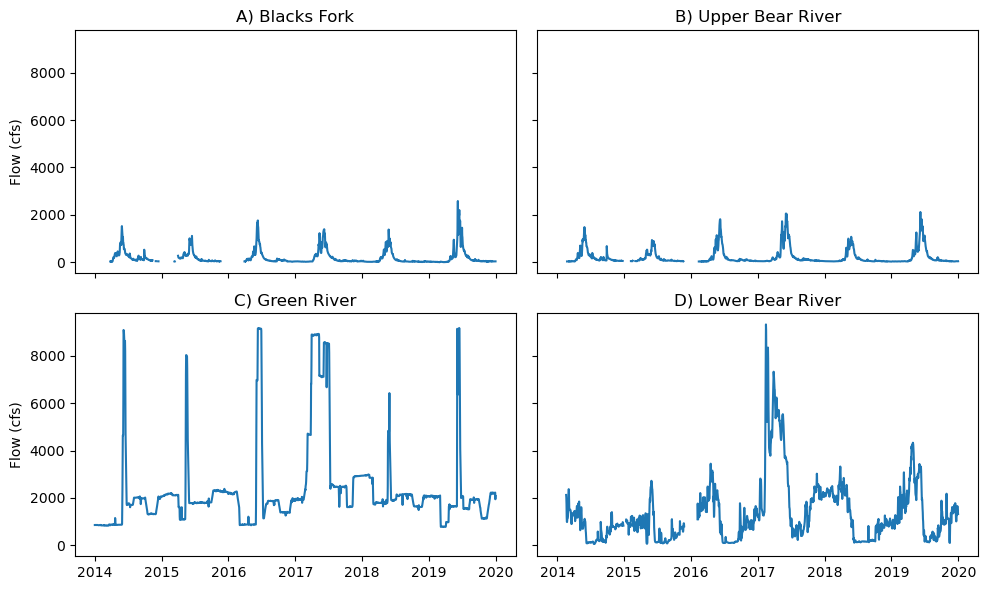

In [8]:
#create 4 subplots of the subsets
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True) #size = width, height

data = [blackfork_subset, greenriver_subset, bear_upper_subset, bear_lower_subset]

for df in data:
    df['Datetime'] = pd.to_datetime(df['Datetime'])

axes[0, 0].plot(blackfork_subset['Datetime'], blackfork_subset['USGS_flow'])
axes[0, 0].set_title('A) Blacks Fork')
axes[0, 0].set_ylabel('Flow (cfs)')
axes[0, 1].plot(bear_upper_subset['Datetime'], bear_upper_subset['USGS_flow'])
axes[0, 1].set_title('B) Upper Bear River')
axes[1, 0].plot(greenriver_subset['Datetime'], greenriver_subset['USGS_flow'])
axes[1, 0].set_title('C) Green River')
axes[1, 0].set_ylabel('Flow (cfs)')
axes[1, 1].plot(bear_lower_subset['Datetime'], bear_lower_subset['USGS_flow'])
axes[1, 1].set_title('D) Lower Bear River')
axes[1, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[1, 1].xaxis.set_major_locator(mdates.YearLocator())
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()

#save plot to media folder
plt.savefig('media/initial_ts_plot.png', dpi=500)

plt.show()

**Compare and Contrast:** How do the different streams compare (timing, magnitude, other)?

The headwater catchments (Blacks Fork and the upper Bear River) have the lowest flow of the 4 datasets, while the rivers that are downstream of many tributaries and reservoirs have significantly higher flow (Green River and lower Bear River). 2017 looks like a big water year for the lower Bear River, although the headwaters don't show it. For the Green River below Flaming Gorge dam in 2017, there is an interesting sustained peak - perhaps a highly managed release of water? In fact, all of the Green River's peak flows start very abruptly compared to the Bear River, and the flows are sometimes relatively steady over a few months. Although it's hard to tell from my figure above, the timing of the Green River and Blacks Fork peak line up and the timing of the upper and lower Bears almost line up; the upper Bear seems to peak later, perhaps because of the later melt season in the Uintas. 

In [9]:
#save subsets as csvs in the data folder for easy access later

# blackfork_subset.to_csv("data/Blackfork.csv", index=False)
# bear_lower_subset.to_csv("data/Bear_Lower.csv", index=False)
# bear_upper_subset.to_csv("data/Bear_Upper.csv", index=False)
# greenriver_subset.to_csv("data/Greenriver.csv", index=False)

#commented out the above lines to avoid overwriting the current csvs in the data folder, but they can be uncommented if needed